# Phase 1: Problem Understanding

## Project Title

Bike Rental Demand Prediction Using Linear Regression

### 1. Problem Statement

Bike rental companies often face challenges in estimating the number of bicycles customers will rent under different weather, seasonal, and time conditions. This project aims to develop a Machine Learning model using Linear Regression to predict bike rental demand based on historical data. The predictions can help businesses plan bicycle availability, manage resources, and improve operational efficiency.

### 2. Target Variable

The target variable is `cnt`, which represents the total number of bike rentals.

The model will predict the expected number of bike rentals based on the selected input features.

### 3. Important Features

* Temperature (`temp`)
* Humidity (`hum`)
* Weather Situation (`weathersit`)
* Season (`season`)
* Hour (`hr`)
* Day of Week (`weekday`)
* Working Day (`workingday`)
* Holiday (`holiday`)
* Windspeed (`windspeed`)

### 4. Business Use Case

The prediction model can help bike-sharing companies estimate rental demand during different hours and weather conditions. It can support resource planning, bicycle distribution, peak-hour preparation, and improved customer service by reducing the chances of insufficient bicycle availability.

### 5. Machine Learning Type

Supervised Machine Learning — Regression.

### 6. Algorithm

Linear Regression.

### 7. Expected Outcome

A trained model that predicts numerical bike rental demand using weather, seasonal, and time-related features.


# Phase 2: Dataset Collection & Exploration

## 1. Dataset Information

Dataset Name: Bike Sharing Dataset

Dataset Source: UCI Machine Learning Repository

Dataset Link: https://archive.ics.uci.edu/dataset/275/bike+sharing+dataset

File Used: hour.csv

File Format: CSV (Comma-Separated Values)

Data Description: The dataset contains hourly bike rental counts along with weather, seasonal, and time-related information.

Target Variable: cnt

## 2. Dataset Exploration

In this phase, Pandas will be used to inspect the dataset preview, shape, columns, data types, and statistical summary.


In [2]:
import pandas as pd
import zipfile
import urllib.request

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00275/Bike-Sharing-Dataset.zip"

urllib.request.urlretrieve(url, "bike_sharing.zip")

with zipfile.ZipFile("bike_sharing.zip", "r") as zip_ref:
    zip_ref.extractall("bike_data")

print("Dataset downloaded successfully!")

Dataset downloaded successfully!


In [3]:
df = pd.read_csv("bike_data/hour.csv")

print("Dataset loaded successfully!")

Dataset loaded successfully!


In [4]:
df.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


In [5]:
df.shape

(17379, 17)

In [6]:
df.columns

Index(['instant', 'dteday', 'season', 'yr', 'mnth', 'hr', 'holiday', 'weekday',
       'workingday', 'weathersit', 'temp', 'atemp', 'hum', 'windspeed',
       'casual', 'registered', 'cnt'],
      dtype='object')

In [7]:
df.dtypes

,0
instant,int64
dteday,object
season,int64
yr,int64
mnth,int64
hr,int64
holiday,int64
weekday,int64
workingday,int64
weathersit,int64


In [8]:
df.describe()

,instant,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,17379.0000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000
mean,8690.0000,2.501640,0.502561,6.537775,11.546752,0.028770,3.003683,0.682721,1.425283,0.496987,0.475775,0.627229,0.190098,35.676218,153.786869,189.463088
std,5017.0295,1.106918,0.500008,3.438776,6.914405,0.167165,2.005771,0.465431,0.639357,0.192556,0.171850,0.192930,0.122340,49.305030,151.357286,181.387599
min,1.0000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,4345.5000,2.000000,0.000000,4.000000,6.000000,0.000000,1.000000,0.000000,1.000000,0.340000,0.333300,0.480000,0.104500,4.000000,34.000000,40.000000
50%,8690.0000,3.000000,1.000000,7.000000,12.000000,0.000000,3.000000,1.000000,1.000000,0.500000,0.484800,0.630000,0.194000,17.000000,115.000000,142.000000
75%,13034.5000,3.000000,1.000000,10.000000,18.000000,0.000000,5.000000,1.000000,2.000000,0.660000,0.621200,0.780000,0.253700,48.000000,220.000000,281.000000
max,17379.0000,4.000000,1.000000,12.000000,23.000000,1.000000,6.000000,1.000000,4.000000,1.000000,1.000000,1.000000,0.850700,367.000000,886.000000,977.000000


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     17379 non-null  int64  
 1   dteday      17379 non-null  object 
 2   season      17379 non-null  int64  
 3   yr          17379 non-null  int64  
 4   mnth        17379 non-null  int64  
 5   hr          17379 non-null  int64  
 6   holiday     17379 non-null  int64  
 7   weekday     17379 non-null  int64  
 8   workingday  17379 non-null  int64  
 9   weathersit  17379 non-null  int64  
 10  temp        17379 non-null  float64
 11  atemp       17379 non-null  float64
 12  hum         17379 non-null  float64
 13  windspeed   17379 non-null  float64
 14  casual      17379 non-null  int64  
 15  registered  17379 non-null  int64  
 16  cnt         17379 non-null  int64  
dtypes: float64(4), int64(12), object(1)
memory usage: 2.3+ MB


# Project Phase 3 — Data Cleaning & Preprocessing

## Objective

The objective of this phase is to inspect the Bike Sharing Dataset, identify data quality issues, clean the data, encode categorical features, and prepare the final dataset for machine learning.


In [10]:
df.isnull().sum()

,0
instant,0
dteday,0
season,0
yr,0
mnth,0
hr,0
holiday,0
weekday,0
workingday,0
weathersit,0


In [11]:
print("Total Missing Values:", df.isnull().sum().sum())

Total Missing Values: 0


In [12]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


In [13]:
df_clean = df.drop_duplicates().copy()

print("Shape Before Cleaning:", df.shape)
print("Shape After Removing Duplicates:", df_clean.shape)

Shape Before Cleaning: (17379, 17)
Shape After Removing Duplicates: (17379, 17)


In [14]:
df_clean.dtypes

,0
instant,int64
dteday,object
season,int64
yr,int64
mnth,int64
hr,int64
holiday,int64
weekday,int64
workingday,int64
weathersit,int64


In [15]:
df_clean["dteday"] = pd.to_datetime(df_clean["dteday"])

print(df_clean["dteday"].dtype)

datetime64[ns]


In [16]:
df_clean["day"] = df_clean["dteday"].dt.day

df_clean[["dteday", "day"]].head()

,dteday,day
0,2011-01-01,1
1,2011-01-01,1
2,2011-01-01,1
3,2011-01-01,1
4,2011-01-01,1


In [17]:
df_clean = df_clean.drop(
    columns=["instant", "dteday", "casual", "registered"]
)

print("Remaining Columns:")
print(df_clean.columns)

Remaining Columns:
Index(['season', 'yr', 'mnth', 'hr', 'holiday', 'weekday', 'workingday',
       'weathersit', 'temp', 'atemp', 'hum', 'windspeed', 'cnt', 'day'],
      dtype='object')


In [18]:
categorical_cols = [
    "season",
    "yr",
    "mnth",
    "hr",
    "holiday",
    "weekday",
    "workingday",
    "weathersit"
]

df_encoded = pd.get_dummies(
    df_clean,
    columns=categorical_cols,
    drop_first=True,
    dtype=int
)

print("Encoded Dataset Shape:", df_encoded.shape)
df_encoded.head()

Encoded Dataset Shape: (17379, 55)


,temp,atemp,hum,windspeed,cnt,day,season_2,season_3,season_4,yr_1,...,weekday_1,weekday_2,weekday_3,weekday_4,weekday_5,weekday_6,workingday_1,weathersit_2,weathersit_3,weathersit_4
0,0.24,0.2879,0.81,0.0,16,1,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
1,0.22,0.2727,0.80,0.0,40,1,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
2,0.22,0.2727,0.80,0.0,32,1,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
3,0.24,0.2879,0.75,0.0,13,1,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
4,0.24,0.2879,0.75,0.0,1,1,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0


In [19]:
print("Final Dataset Shape:", df_encoded.shape)

print("\nMissing Values:")
print(df_encoded.isnull().sum().sum())

print("\nDuplicate Rows:")
print(df_encoded.duplicated().sum())

print("\nFinal Columns:")
print(df_encoded.columns.tolist())

Final Dataset Shape: (17379, 55)

Missing Values:
0

Duplicate Rows:
0

Final Columns:
['temp', 'atemp', 'hum', 'windspeed', 'cnt', 'day', 'season_2', 'season_3', 'season_4', 'yr_1', 'mnth_2', 'mnth_3', 'mnth_4', 'mnth_5', 'mnth_6', 'mnth_7', 'mnth_8', 'mnth_9', 'mnth_10', 'mnth_11', 'mnth_12', 'hr_1', 'hr_2', 'hr_3', 'hr_4', 'hr_5', 'hr_6', 'hr_7', 'hr_8', 'hr_9', 'hr_10', 'hr_11', 'hr_12', 'hr_13', 'hr_14', 'hr_15', 'hr_16', 'hr_17', 'hr_18', 'hr_19', 'hr_20', 'hr_21', 'hr_22', 'hr_23', 'holiday_1', 'weekday_1', 'weekday_2', 'weekday_3', 'weekday_4', 'weekday_5', 'weekday_6', 'workingday_1', 'weathersit_2', 'weathersit_3', 'weathersit_4']


In [20]:
print("Target Column: cnt")
print(df_encoded["cnt"].head())

Target Column: cnt
0    16
1    40
2    32
3    13
4     1
Name: cnt, dtype: int64


In [21]:
df_encoded.to_csv("bike_rental_cleaned.csv", index=False)

print("Final dataset saved successfully!")

Final dataset saved successfully!


In [22]:
from google.colab import files

files.download("bike_rental_cleaned.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Project Phase 4 — Exploratory Data Analysis (EDA)

## Objective

The objective of this phase is to explore the cleaned Bike Sharing Dataset using statistical analysis and visualizations. The analysis focuses on understanding rental demand patterns based on weather, season, hour, and day of the week, and identifying features that may help predict total bike rentals.


In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

print("Visualization libraries imported successfully!")

Visualization libraries imported successfully!


In [24]:
print("Dataset Shape:", df_clean.shape)

print("\nFirst 5 Rows:")
display(df_clean.head())

Dataset Shape: (17379, 14)

First 5 Rows:


,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,cnt,day
0,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,16,1
1,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,40,1
2,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,32,1
3,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,13,1
4,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,1,1


In [25]:
hourly_demand = df_clean.groupby("hr")["cnt"].mean()

print("Average Bike Rentals by Hour:")
display(hourly_demand)

Average Bike Rentals by Hour:


,cnt
hr,
0,53.898072
1,33.375691
2,22.869930
3,11.727403
4,6.352941
5,19.889819
6,76.044138
7,212.064649
8,359.011004


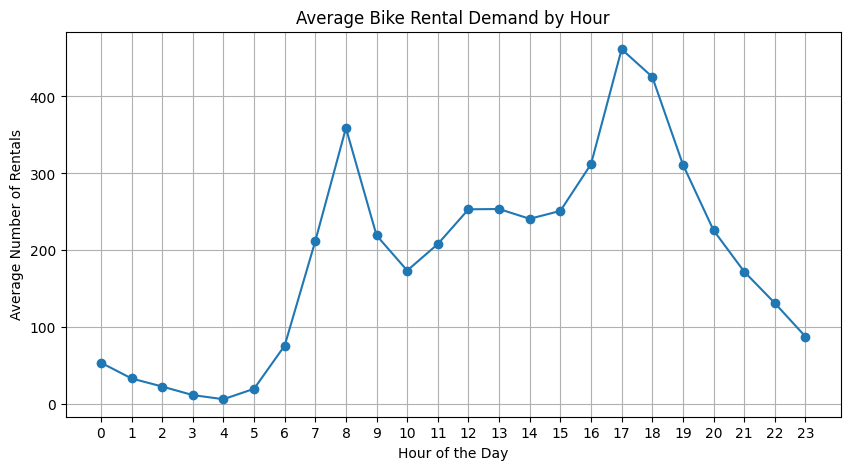

In [26]:
plt.figure(figsize=(10, 5))

plt.plot(
    hourly_demand.index,
    hourly_demand.values,
    marker="o"
)

plt.title("Average Bike Rental Demand by Hour")
plt.xlabel("Hour of the Day")
plt.ylabel("Average Number of Rentals")

plt.xticks(range(24))
plt.grid(True)

plt.show()

In [27]:
weather_demand = df_clean.groupby("weathersit")["cnt"].mean()

print("Average Bike Rentals by Weather Condition:")
display(weather_demand)

Average Bike Rentals by Weather Condition:


,cnt
weathersit,
1,204.869272
2,175.165493
3,111.579281
4,74.333333


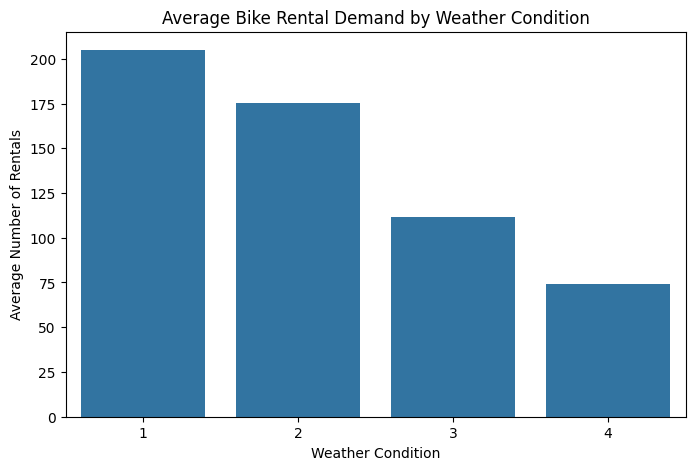

In [28]:
plt.figure(figsize=(8, 5))

sns.barplot(
    x=weather_demand.index,
    y=weather_demand.values
)

plt.title("Average Bike Rental Demand by Weather Condition")
plt.xlabel("Weather Condition")
plt.ylabel("Average Number of Rentals")

plt.show()

In [29]:
season_demand = df_clean.groupby("season")["cnt"].mean()

print("Average Bike Rentals by Season:")
display(season_demand)

Average Bike Rentals by Season:


,cnt
season,
1,111.114569
2,208.344069
3,236.016237
4,198.868856


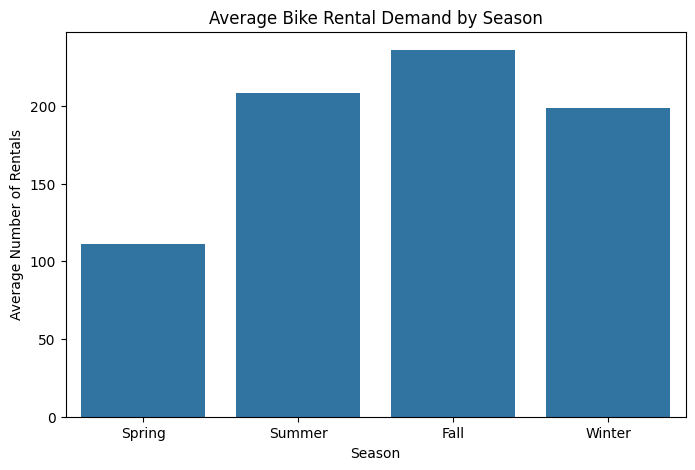

In [30]:
plt.figure(figsize=(8, 5))

sns.barplot(
    x=season_demand.index,
    y=season_demand.values
)

plt.title("Average Bike Rental Demand by Season")
plt.xlabel("Season")
plt.ylabel("Average Number of Rentals")

plt.xticks(
    [0, 1, 2, 3],
    ["Spring", "Summer", "Fall", "Winter"]
)

plt.show()

In [31]:
workingday_demand = df_clean.groupby("workingday")["cnt"].mean()

print("Average Bike Rentals by Working Day:")
display(workingday_demand)

Average Bike Rentals by Working Day:


,cnt
workingday,
0,181.405332
1,193.207754


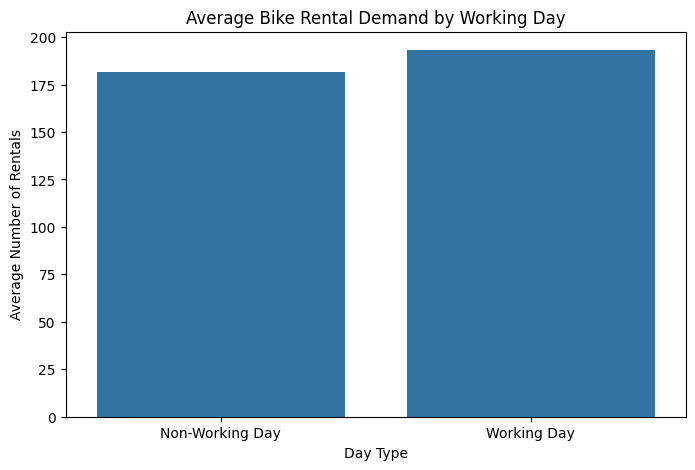

In [32]:
plt.figure(figsize=(8, 5))

sns.barplot(
    x=workingday_demand.index,
    y=workingday_demand.values
)

plt.title("Average Bike Rental Demand by Working Day")
plt.xlabel("Day Type")
plt.ylabel("Average Number of Rentals")

plt.xticks(
    [0, 1],
    ["Non-Working Day", "Working Day"]
)

plt.show()

In [33]:
correlation = df_clean.corr(numeric_only=True)

print("Correlation with Bike Rental Count (cnt):")
display(correlation["cnt"].sort_values(ascending=False))

Correlation with Bike Rental Count (cnt):


,cnt
cnt,1.000000
temp,0.404772
atemp,0.400929
hr,0.394071
yr,0.250495
season,0.178056
mnth,0.120638
windspeed,0.093234
workingday,0.030284
weekday,0.026900


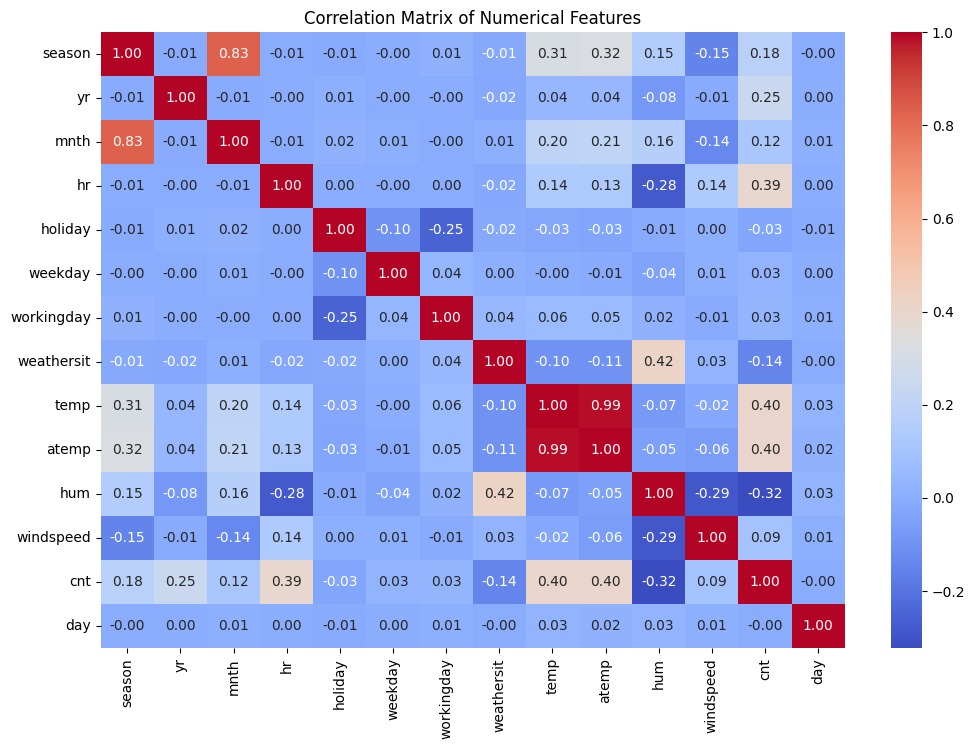

In [34]:
plt.figure(figsize=(12, 8))

sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Correlation Matrix of Numerical Features")
plt.show()

Phase 5: Linear Regression Model

In this phase, we will train a Linear Regression model to predict bike rental demand.

We will separate the features from the target variable, split the dataset into training and testing sets, train the model, and generate sample predictions.

In [35]:
X = df_clean.drop(columns=["cnt"])
y = df_clean["cnt"]

print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

Features Shape: (17379, 13)
Target Shape: (17379,)


In [36]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training Features Shape:", X_train.shape)
print("Testing Features Shape:", X_test.shape)
print("Training Target Shape:", y_train.shape)
print("Testing Target Shape:", y_test.shape)

Training Features Shape: (13903, 13)
Testing Features Shape: (3476, 13)
Training Target Shape: (13903,)
Testing Target Shape: (3476,)


In [37]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

print("Linear Regression model trained successfully!")

Linear Regression model trained successfully!


In [38]:
y_pred = model.predict(X_test)

comparison = pd.DataFrame({
    "Actual": y_test.iloc[:10].values,
    "Predicted": y_pred[:10]
})

display(comparison)

,Actual,Predicted
0,425,449.525059
1,88,206.059136
2,4,55.972102
3,526,382.017526
4,13,-20.780505
5,32,7.115084
6,706,345.745431
7,26,26.651533
8,2,122.427768
9,21,98.316636


Phase 6: Model Evaluation

In this phase, we will evaluate the performance of our Linear Regression model using regression evaluation metrics.

We will calculate Mean Absolute Error (MAE), Mean Squared Error (MSE), Root Mean Squared Error (RMSE), and R² Score. We will also visualize actual and predicted bike rental demand to understand the model's performance.

In [39]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("Evaluation metrics imported successfully!")

Evaluation metrics imported successfully!


In [40]:
mae = mean_absolute_error(y_test, y_pred)

print("Mean Absolute Error (MAE):", mae)

Mean Absolute Error (MAE): 104.79088187855695


In [41]:
mse = mean_squared_error(y_test, y_pred)

print("Mean Squared Error (MSE):", mse)

Mean Squared Error (MSE): 19375.74150348481


In [42]:
import numpy as np

rmse = np.sqrt(mse)

print("Root Mean Squared Error (RMSE):", rmse)

Root Mean Squared Error (RMSE): 139.19677260441352


In [43]:
r2 = r2_score(y_test, y_pred)

print("R² Score:", r2)

R² Score: 0.3881102222986975


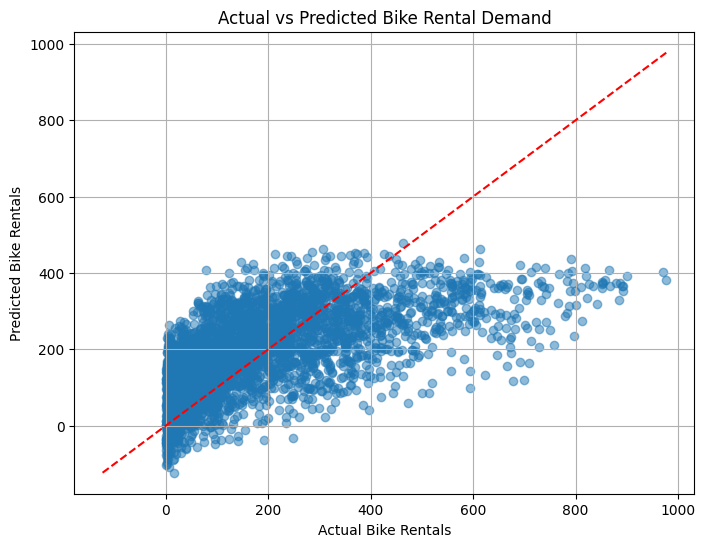

In [44]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred, alpha=0.5)

lower = min(y_test.min(), y_pred.min())
upper = max(y_test.max(), y_pred.max())

plt.plot([lower, upper], [lower, upper], "r--")

plt.title("Actual vs Predicted Bike Rental Demand")
plt.xlabel("Actual Bike Rentals")
plt.ylabel("Predicted Bike Rentals")
plt.grid(True)

plt.show()

# Phase 7 — Make Predictions Using the Trained Model

In this phase, the trained Linear Regression model will be used to predict bike rental demand for new and unseen input conditions.

In [62]:
print("Trained model is ready.")
print("Model:", model)

Trained model is ready.
Model: LinearRegression()


In [63]:
print("Features required by the model:")
print(model.feature_names_in_)

Features required by the model:
['season' 'yr' 'mnth' 'hr' 'holiday' 'weekday' 'workingday' 'weathersit'
 'temp' 'atemp' 'hum' 'windspeed' 'day']


In [64]:
import ipywidgets as widgets
from IPython.display import display, HTML

In [65]:
display(HTML("""
<div style="
    background:#1f2937;
    padding:25px;
    border-radius:15px;
    text-align:center;
    color:white;
    margin-bottom:20px;
">
    <h1 style="margin:0;">🚲 Bike Rental Demand Predictor</h1>
    <p style="margin:8px 0 0 0; font-size:16px;">
        Predict bike rental demand using weather and time conditions
    </p>
</div>
"""))

In [66]:
season = widgets.Dropdown(
    options=[
        ('Spring', 1),
        ('Summer', 2),
        ('Fall', 3),
        ('Winter', 4)
    ],
    value=2,
    description='Season:',
    style={'description_width': '120px'},
    layout=widgets.Layout(width='350px')
)

month = widgets.IntSlider(
    value=6,
    min=1,
    max=12,
    step=1,
    description='Month:',
    style={'description_width': '120px'},
    layout=widgets.Layout(width='350px')
)

day = widgets.IntSlider(
    value=15,
    min=1,
    max=31,
    step=1,
    description='Day:',
    style={'description_width': '120px'},
    layout=widgets.Layout(width='350px')
)

hour = widgets.IntSlider(
    value=10,
    min=0,
    max=23,
    step=1,
    description='Hour:',
    style={'description_width': '120px'},
    layout=widgets.Layout(width='350px')
)

weather = widgets.Dropdown(
    options=[
        ('Clear / Few Clouds', 1),
        ('Mist / Cloudy', 2),
        ('Light Rain / Snow', 3),
        ('Heavy Rain / Snow', 4)
    ],
    value=1,
    description='Weather:',
    style={'description_width': '120px'},
    layout=widgets.Layout(width='350px')
)

temperature = widgets.FloatSlider(
    value=0.5,
    min=0,
    max=1,
    step=0.01,
    description='Temperature:',
    style={'description_width': '120px'},
    layout=widgets.Layout(width='350px')
)

humidity = widgets.FloatSlider(
    value=0.5,
    min=0,
    max=1,
    step=0.01,
    description='Humidity:',
    style={'description_width': '120px'},
    layout=widgets.Layout(width='350px')
)

windspeed = widgets.FloatSlider(
    value=0.2,
    min=0,
    max=1,
    step=0.01,
    description='Wind Speed:',
    style={'description_width': '120px'},
    layout=widgets.Layout(width='350px')
)

workingday = widgets.Dropdown(
    options=[
        ('Yes', 1),
        ('No', 0)
    ],
    value=1,
    description='Working Day:',
    style={'description_width': '120px'},
    layout=widgets.Layout(width='350px')
)

In [67]:
predict_button = widgets.Button(
    description='🚲 Predict Bike Demand',
    button_style='primary',
    layout=widgets.Layout(
        width='350px',
        height='45px'
    )
)

prediction_output = widgets.Output()

In [68]:
input_box = widgets.VBox([
    widgets.HTML("<h3>📋 Enter Conditions</h3>"),
    season,
    month,
    day,
    hour,
    weather,
    temperature,
    humidity,
    windspeed,
    workingday
])

display(input_box)

In [69]:
def predict_bike_demand(button):

    with prediction_output:
        prediction_output.clear_output()

        input_data = pd.DataFrame({
            'season': [season.value],
            'yr': [1],
            'mnth': [month.value],
            'hr': [hour.value],
            'holiday': [0],
            'weekday': [2],
            'workingday': [workingday.value],
            'weathersit': [weather.value],
            'temp': [temperature.value],
            'atemp': [temperature.value],
            'hum': [humidity.value],
            'windspeed': [windspeed.value],
            'day': [day.value]
        })

        prediction = model.predict(input_data)[0]
        predicted_bikes = max(0, round(prediction))

        display(HTML(f"""
        <div style="
            background:#f3f4f6;
            border:2px solid #9ca3af;
            padding:20px;
            border-radius:15px;
            text-align:center;
            width:310px;
            margin-top:15px;
        ">
            <h3>🚲 Predicted Bike Demand</h3>
            <h1>{predicted_bikes} Bikes</h1>
            <p>The model's predicted rental demand for these conditions.</p>
        </div>
        """))

In [70]:
predict_button.on_click(predict_bike_demand)

display(
    widgets.VBox([
        predict_button,
        prediction_output
    ])
)

In [75]:
from IPython.display import display, HTML
import ipywidgets as widgets

# Create a fresh prediction output area
final_output = widgets.Output()

# Prediction button
final_predict_button = widgets.Button(
    description='🚲 Predict Bike Demand',
    button_style='primary',
    layout=widgets.Layout(
        width='350px',
        height='50px'
    )
)

# Prediction function
def final_prediction(button):

    with final_output:
        final_output.clear_output()

        input_data = pd.DataFrame({
            'season': [season.value],
            'yr': [1],
            'mnth': [month.value],
            'hr': [hour.value],
            'holiday': [0],
            'weekday': [2],
            'workingday': [workingday.value],
            'weathersit': [weather.value],
            'temp': [temperature.value],
            'atemp': [temperature.value],
            'hum': [humidity.value],
            'windspeed': [windspeed.value],
            'day': [day.value]
        })

        prediction = model.predict(input_data)[0]
        predicted_bikes = max(0, round(prediction))

        display(HTML(f"""
        <div style="
            background:#f8fafc;
            border:2px solid #374151;
            border-radius:12px;
            padding:18px;
            margin-top:15px;
            text-align:center;
            width:500px;
        ">
            <h3>🚲 Predicted Bike Demand</h3>
            <h1>{predicted_bikes} Bikes</h1>
            <p>Estimated rental demand for the selected conditions.</p>
        </div>
        """))

# Connect button
final_predict_button.on_click(final_prediction)

# Input section
inputs = widgets.VBox([
    widgets.HTML("<h2>📋 Enter Weather & Time Conditions</h2>"),
    season,
    month,
    day,
    hour,
    weather,
    temperature,
    humidity,
    windspeed,
    workingday,
    widgets.HTML("<br>"),
    final_predict_button,
    final_output
])

# Main application heading
display(HTML("""
<div style="
    background:#1f2937;
    color:white;
    padding:25px;
    border-radius:15px;
    width:550px;
    text-align:center;
    margin-bottom:15px;
">
    <h1>🚲 Bike Rental Demand Predictor</h1>
    <p>Machine Learning Prediction Application</p>
</div>
"""))

display(inputs)